# 3교시 실습 — 지저분한 데이터 길들이기 🧹

> **사용법**: 🔵 **수업**(함께 실행) · 🟡 **셀프**(직접 채우기 `____`).
> 정답본(`_solution`)에는 **실행 결과 + 💡해석**이 셀마다 달려 있습니다.

---

## 🗂 오늘의 미션

분석가에게 오는 데이터는 교과서처럼 깨끗하지 않습니다. **현실은 지저분합니다.**
오늘 두 개의 진짜 데이터를 정제합니다.

1. **🏠 부동산** — 국토교통부 아파트 실거래가 (글자로 된 금액, 빈 칸 가득)
2. **💰 금융** — 금(Gold) 시세 시계열 (수집이 끊긴 구멍들)

특히 **결측치(빈 칸)** 를 *눈으로 보고*, **여러 방법으로 메우는 법**을 배웁니다 —
버리기부터 시작해서, 마지막엔 **AI가 쓰는 알고리즘 방식**까지.

> 💡 분석가는 시간의 절반 이상을 '정제'에 씁니다. 화려하진 않지만, 여기서 분석의 품질이 갈립니다.

## 🎯 학습 목표 — 이 실습을 끝내면

- 글자로 된 숫자(쉼표 포함)를 **진짜 숫자로 변환**할 수 있다
- **결측치(빈 칸)** 가 어디에 얼마나 있는지 찾아낼 수 있다
- 결측치를 **5가지 방법**으로 처리할 수 있다 (버리기·평균/중앙값·앞값/보간·KNN)
- 상황에 맞는 **결측 처리 방법을 고를** 수 있다
- **'정제도 분석가의 판단'** 임을 설명할 수 있다

## 0. 준비  🔵

In [1]:
import pandas as pd                      # 표(데이터프레임) 다루는 도구
import numpy as np                       # 숫자·배열 계산 도구
import matplotlib.pyplot as plt          # 그래프 그리는 도구
import seaborn as sns                    # 예쁜 그래프(히트맵 등) 도구
import os, urllib.request                # 파일 확인·다운로드용
from matplotlib import font_manager as fm  # 한글 폰트 등록용

DATA_BASE = "https://raw.githubusercontent.com/acho98/gunyang-data/main/"  # 데이터가 올라간 인터넷 주소
def set_korean_font():                    # 그래프에 한글이 깨지지 않게 폰트 설정하는 함수
    cands = ["../data/BMDOHYEON.ttf", "data/BMDOHYEON.ttf", "BMDOHYEON.ttf"]  # 폰트 파일을 찾을 후보 위치들
    if not any(os.path.exists(p) for p in cands):   # 폰트가 어디에도 없으면
        try: urllib.request.urlretrieve(DATA_BASE + "BMDOHYEON.ttf", "BMDOHYEON.ttf")  # 인터넷에서 내려받기
        except Exception: pass
    for p in cands:                       # 후보 위치를 하나씩 확인
        if os.path.exists(p):             # 폰트 파일이 실제로 있으면
            try:
                fm.fontManager.addfont(p)  # 그 폰트를 matplotlib에 등록
                plt.rcParams["font.family"] = fm.FontProperties(fname=p).get_name()  # 기본 글꼴로 지정
                plt.rcParams["axes.unicode_minus"] = False; return  # 마이너스 기호 깨짐 방지 후 종료
            except Exception: pass
    print("(안내) 한글 폰트를 못 찾았어요. 영문은 정상입니다.")
set_korean_font()                         # 위 함수 실행(폰트 적용)
print("준비 완료!")

준비 완료!


# Part A. 🏠 부동산 실거래가 정제

> 부장님: *"국토부에서 받은 2021년 5월 전국 아파트 실거래가야. 평균 가격이랑 비싼 동네 좀 뽑아줘. 근데... 데이터가 좀 지저분할 거야."*

### A-1. 입수하고 첫인상 보기  🔵

In [2]:
apt = pd.read_csv(DATA_BASE + "apt_realprice_202105.csv")  # 인터넷에서 아파트 실거래가 CSV 불러오기
print("거래 건수:", len(apt))                              # 전체 행(거래) 개수 출력
apt.head()                                                 # 맨 앞 5줄 미리보기

거래 건수: 57805


,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),층,건축년도,도로명,해제사유발생일
0,강원도 강릉시 견소동,202,202,0.0,송정한신,84.945,202105,4,"19,500",2,1997,경강로2539번길 8,NaN
1,강원도 강릉시 견소동,202,202,0.0,송정한신,84.945,202105,4,"19,500",8,1997,경강로2539번길 8,NaN
2,강원도 강릉시 견소동,202,202,0.0,송정한신,84.945,202105,4,"19,500",8,1997,경강로2539번길 8,20210528.0
3,강원도 강릉시 견소동,202,202,0.0,송정한신,59.800,202105,6,"13,800",3,1997,경강로2539번길 8,NaN
4,강원도 강릉시 견소동,202,202,0.0,송정한신,84.945,202105,24,"19,300",2,1997,경강로2539번길 8,NaN


💡 **해석**: 전국 **57,805건**의 실제 거래. `시군구·단지명·전용면적·거래금액·층·건축년도` 등 13개 정보. 한 줄이 거래 한 건이에요. 그런데 자세히 보면 문제가 숨어 있습니다 → 다음 셀.

### A-2. 타입 점검 — `info()`  🟡
> 💡 힌트: `apt.info()`

In [3]:
apt.info()  # 컬럼별 타입(글자/숫자)과 결측(빈 칸) 개수 한눈에 점검

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57805 entries, 0 to 57804
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   시군구       57805 non-null  object 
 1   번지        57800 non-null  object 
 2   본번        57804 non-null  object 
 3   부번        57804 non-null  float64
 4   단지명       57805 non-null  object 
 5   전용면적(㎡)   57805 non-null  float64
 6   계약년월      57805 non-null  int64  
 7   계약일       57805 non-null  int64  
 8   거래금액(만원)  57805 non-null  object 
 9   층         57805 non-null  int64  
 10  건축년도      57805 non-null  int64  
 11  도로명       57805 non-null  object 
 12  해제사유발생일   1317 non-null   float64
dtypes: float64(3), int64(4), object(6)
memory usage: 5.7+ MB


💡 **해석**: 두 가지 문제 발견!
1. `거래금액(만원)` 이 **object(글자)** — 숫자여야 평균을 구하는데!
2. `해제사유발생일` 의 Non-Null이 **1,317개뿐** (전체 57,805 중) → **거의 다 비었다**

분석가는 이렇게 `info()` 로 '문제부터 찾습니다'. 하나씩 고쳐봅시다.

### A-3. 문제① 글자로 된 금액 → 숫자  🔵
`거래금액`이 `"19,500"` 처럼 **쉼표가 든 글자**라 계산이 안 됩니다. 쉼표를 지우고 숫자로 바꿉니다. (핵심 기법!)

In [4]:
print("바꾸기 전:", apt["거래금액(만원)"].iloc[0], "/ 타입:", apt["거래금액(만원)"].dtype)  # 첫 값과 타입 확인(글자)
apt["거래금액(만원)"] = apt["거래금액(만원)"].str.replace(",", "").astype(int)  # "19,500"(글자)→쉼표 지우고→19500(숫자)
print("바꾼 후 :", apt["거래금액(만원)"].iloc[0], "/ 타입:", apt["거래금액(만원)"].dtype)  # 숫자(int)로 바뀐 것 확인
print("이제 평균이 구해진다 → {:,.0f}만원".format(apt["거래금액(만원)"].mean()))  # 숫자가 됐으니 평균 계산 가능

바꾸기 전: 19,500 / 타입: object
바꾼 후 : 19500 / 타입: int64
이제 평균이 구해진다 → 35,127만원


💡 **해석**: `.str.replace(",","")` 로 쉼표를 지우고 `.astype(int)` 로 정수로 변환. 글자(object) → 숫자(int)가 되니 **평균 35,127만원**이 계산됩니다. *정제 먼저, 계산은 그다음!*

## 🔍 결측치(빈 칸) 다루기 — 오늘의 핵심

데이터에 비어 있는 칸(`NaN`)을 **결측치**라고 합니다. 분석가는 이걸 ① **눈으로 확인**하고 ② **방법을 골라 처리**합니다.

### A-4. 결측 탐색 — 어디에 얼마나?  🟡
> 💡 힌트: `apt.isnull().sum()`

In [5]:
apt.isnull().sum().sort_values(ascending=False)  # 빈 칸 여부(True)를 컬럼별로 합산→많은 순 정렬

해제사유발생일     56488
번지              5
본번              1
부번              1
시군구             0
단지명             0
전용면적(㎡)         0
계약년월            0
계약일             0
거래금액(만원)        0
층               0
건축년도            0
도로명             0
dtype: int64

💡 **해석**: `해제사유발생일` 이 **56,488개** 비었습니다(전체의 97.7%!). 그 외 `번지`(5), `본번`·`부번`(각 1개)은 아주 조금. 숫자로 보니 명확하죠. 그런데 **그림으로 보면 더 한눈에** 들어옵니다 → 다음.

### A-5. 결측 시각화 ① — 막대그래프  🔵
결측 개수를 막대로 그리면 '얼마나 심각한지'가 한눈에 보입니다.

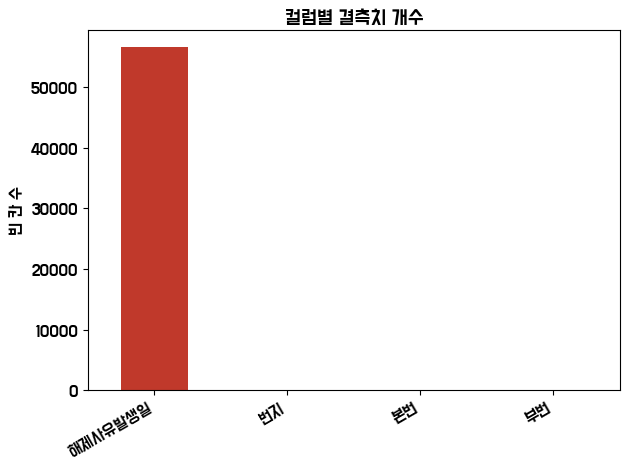

In [6]:
miss = apt.isnull().sum().sort_values(ascending=False)  # 컬럼별 결측 개수(많은 순)
miss = miss[miss > 0]                      # 결측이 있는 컬럼만 남기기
miss.plot(kind="bar", color="#C0392B")     # 막대그래프로 그리기
plt.title("컬럼별 결측치 개수"); plt.ylabel("빈 칸 수"); plt.xticks(rotation=30, ha="right")  # 제목·축·글자기울이기
plt.tight_layout(); plt.show()             # 여백 정리 후 화면에 표시

💡 **해석**: `해제사유발생일` 막대만 압도적으로 높습니다. 이렇게 **한 컬럼이 거의 다 비었으면** 채우는 게 의미 없죠 → 통째로 버리는 게 답입니다.

### A-6. 결측 시각화 ② — 히트맵(지도)  🔵
어느 '위치'가 비었는지 지도처럼 봅니다. (밝은 칸 = 빈 칸)

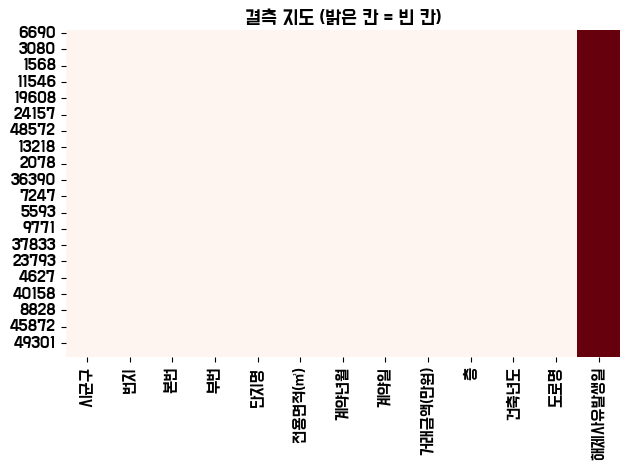

In [7]:
sample = apt.sample(60, random_state=1)     # 60건만 무작위로 뽑기(전체는 너무 커서)
sns.heatmap(sample.isnull(), cbar=False, cmap="Reds")  # 빈 칸이면 빨갛게 칠한 '결측 지도'
plt.title("결측 지도 (밝은 칸 = 빈 칸)"); plt.tight_layout(); plt.show()  # 제목 달고 화면에 표시

💡 **해석**: `해제사유발생일` 열 전체가 빨갛게(거의 다 빔) 칠해집니다. 다른 열은 거의 깨끗하죠. 결측이 **특정 컬럼에 몰려 있다**는 '패턴'을 그림으로 확인 — 이게 시각화의 힘입니다.

## 결측 처리 방법 — 상황에 맞게 고른다

| 방법 | 언제 |
|---|---|
| ① 컬럼 버리기 | 거의 다 비었을 때 |
| ② 행 버리기 | 결측이 아주 적을 때 |
| ③ 대표값 채우기 | 평균·중앙값·최빈값으로 |
| ④ 앞뒤값/보간 | 시계열(시간순) 데이터 |
| ⑤ 알고리즘(KNN) | 여러 변수를 함께 보고 추정 |

Part A에선 ①②③, Part B에서 ④, Part C에서 ⑤를 직접 해봅니다.

> **💉 의료 데이터 한 스푼 — 결측·이상치는 더 조심!**
> 병원 데이터에선 '검사를 안 받은 것'도 결측인데, 이게 **무작위가 아닐 때가 많아요** — 건강해서 안 받았거나, 너무 위중해서 못 받았거나. 즉 **결측 자체가 정보**일 수 있죠. 그래서 무조건 평균으로 채우기 전에 *"왜 비었나"* 를 먼저 생각해야 합니다.
> 이상치도 마찬가지 — 혈압 200을 '이상치'라고 무조건 지우면 **진짜 중증 환자를 버리는 셈**입니다. *오류인지 진짜 신호인지 확인 후* 판단하세요. (자세한 건 5교시 '의료 데이터를 분석할 때'에서!)

### A-7. 방법① 거의 빈 컬럼 버리기  🟡
`해제사유발생일`은 97.7%가 비었으니 통째로 버립니다.
> 💡 힌트: `apt.drop(columns=["해제사유발생일"])`

In [8]:
apt = apt.drop(columns=["해제사유발생일"])  # 97.7% 빈 컬럼은 채워도 의미 없어 통째로 삭제
print("남은 컬럼 수:", apt.shape[1])         # 삭제 후 남은 컬럼 개수 확인

남은 컬럼 수: 12


💡 **해석**: 13개 → 12개 컬럼. 거의 빈 컬럼은 분석에 방해만 되니 버리는 게 깔끔합니다. `axis`가 아니라 `columns=`로 지정하면 직관적이에요.

### A-8. 방법② 결측 적은 행 버리기  🟡
`번지`·`본번` 등은 결측이 몇 개뿐 → 그 행만 버려도 손실이 거의 없습니다.
> 💡 힌트: `apt.dropna()`

In [9]:
before = len(apt)                       # 버리기 전 행 개수 기억
apt = apt.dropna()                      # 빈 칸이 하나라도 있는 행 삭제(결측 적으니 손실 거의 없음)
print(f"{before}건 → {len(apt)}건 (버린 행: {before - len(apt)}건)")  # 몇 건 버려졌는지 확인

57805건 → 57800건 (버린 행: 5건)


💡 **해석**: 단 5건만 버려졌습니다(57,805 → 57,800). 전체의 0.01% — 이 정도면 버려도 분석에 영향 없죠. **결측이 적을 땐 과감히 버리기**가 정답일 때가 많습니다.

### A-9. 방법③ 대표값으로 채우기 (평균 vs 중앙값)  🔵
이번엔 일부러 결측을 만들어 봅니다 — *"몇몇 거래는 금액이 누락됐다"* 는 상황.
그리고 **평균/중앙값**으로 채워 비교합니다. (1교시 '평균의 함정' 복습!)

In [10]:
# [왜 일부러 비우나?] 이 데이터엔 '거래금액' 결측이 거의 없어서,
#  대표값(평균/중앙값)으로 채우는 연습을 할 '빈 칸'이 없습니다.
#  그래서 일부러 2000건을 비워 "몇몇 거래의 금액이 누락된" 실무 상황을 재현합니다.
#  (실무 데이터엔 처음부터 이런 결측이 들어 있어요 — 여기선 연습용으로 만드는 것!)
rng = np.random.default_rng(0)          # 난수 생성기(0=항상 같은 결과 나오게)
apt2 = apt.copy()                        # 원본은 두고 복사본에서 실험
idx = rng.choice(apt2.index, size=2000, replace=False)   # 비울 2000개 행을 무작위로 고름
apt2.loc[idx, "거래금액(만원)"] = np.nan  # 고른 행의 금액을 빈 칸(NaN)으로 만듦
print("일부러 만든 결측:", apt2["거래금액(만원)"].isnull().sum(), "건")  # 비운 개수 확인
print("평균:   {:,.0f}만원".format(apt2["거래금액(만원)"].mean()))    # 결측 무시한 평균
print("중앙값: {:,.0f}만원".format(apt2["거래금액(만원)"].median()))  # 결측 무시한 중앙값(가운데 값)

일부러 만든 결측: 2000 건
평균:   35,115만원
중앙값: 24,500만원


💡 **해석**: 평균(약 35,000)과 중앙값(약 24,500)이 꽤 다릅니다! 집값은 초고가 거래 때문에 **오른쪽으로 치우친 분포** — 평균이 위로 끌려갑니다. 그래서 **채울 땐 중앙값이 더 안전**해요. (1교시 평균의 함정!)

### A-10. 중앙값으로 채우기  🟡
> 💡 힌트: `apt2["거래금액(만원)"].fillna( ... )` 에 중앙값을 넣기

In [11]:
med = apt2["거래금액(만원)"].median()  # 채울 값으로 쓸 중앙값 계산(평균보다 안전)
apt2["거래금액(만원)"] = apt2["거래금액(만원)"].fillna(med)  # 빈 칸을 모두 중앙값으로 메움
print("남은 결측:", apt2["거래금액(만원)"].isnull().sum(), "→ 0이면 성공")  # 결측 0인지 확인

남은 결측: 0 → 0이면 성공


💡 **해석**: 결측이 0이 됐습니다. `fillna(채울값)` 으로 빈 칸을 메웁니다. 범주형(예: 지역)이라면 평균 대신 **최빈값**(`.mode()`)으로 채우면 됩니다 — 데이터 종류에 맞게!

### A-11. 정제 끝 → 분석 맛보기  🟡
깨끗해진 데이터로 **시도별 평균 거래금액 top 5**를 뽑아보세요. (`시군구`의 맨 앞이 시·도)
> 💡 힌트: `apt["시군구"].str.split().str[0]` 로 시·도 추출 후 groupby

In [12]:
apt["시도"] = apt["시군구"].str.split().str[0]  # "서울특별시 강남구..."→공백 기준 첫 단어=시·도
(apt.groupby("시도")["거래금액(만원)"].mean().sort_values(ascending=False).head(5).round(0))  # 시도별 평균→높은순 top5

시도
서울특별시      98421.0
세종특별자치시    48277.0
경기도        43504.0
부산광역시      32577.0
인천광역시      31785.0
Name: 거래금액(만원), dtype: float64

💡 **해석**: 서울이 압도적 1위(평균 약 9.8만 만원 ≈ 9.8억), 그 뒤 세종·경기 순. 정제(타입변환+결측처리)를 했기에 비로소 이런 분석이 가능해진 겁니다. 지저분한 원본으론 평균조차 못 구했죠!

# Part B. 💰 금융 시세 — 시계열의 결측

> 부장님: *"이번엔 금 시세 데이터야. 그래프 그려서 흐름 좀 보자. 근데 수집 서버가 가끔 멈춰서 며칠씩 비었을 거야."*

**시계열**(시간 순서 데이터)의 결측은 부동산과 다르게 처리합니다 — *앞뒤 값*이나 *보간*을 써요.

### B-1. 입수 + 시계열 만들기  🔵

In [13]:
gold = pd.read_csv(DATA_BASE + "gold_5y.csv")    # 금 시세 CSV 불러오기 (컬럼: ds=날짜, y=가격)
gold["ds"] = pd.to_datetime(gold["ds"])          # 글자로 된 날짜를 진짜 '날짜형'으로 변환
gold = gold.sort_values("ds").reset_index(drop=True)  # 날짜순 정렬 후 줄번호 새로 매김
print("기간:", gold["ds"].min().date(), "~", gold["ds"].max().date(), "/", len(gold), "행")  # 시작~끝·행수
gold.head()                                      # 맨 앞 5줄 미리보기

기간: 2000-01-03 ~ 2005-12-30 / 1565 행


,ds,y
0,2000-01-03,290.25
1,2000-01-04,281.50
2,2000-01-05,280.45
3,2000-01-06,279.40
4,2000-01-07,282.10


💡 **해석**: 날짜(ds)와 가격(y)으로 된 전형적인 **시계열**. 날짜순으로 정렬해 뒀습니다. 시계열은 '순서'가 의미를 가져서, 결측 처리도 순서를 활용합니다.

### B-2. 결측 만들기 — 수집이 끊긴 구멍  🔵
*"서버가 멈춰 며칠 데이터가 빈"* 상황을 재현합니다.

In [14]:
# [왜 일부러 비우나?] 시계열 채우기(앞뒤 값·보간)를 연습하려면 '구멍'이 필요합니다.
#  실무에서 서버 장애로 며칠치 데이터가 빠지는 상황을 재현해, 일부러 구멍을 냅니다.
g = gold.tail(120).copy().reset_index(drop=True)   # 최근 120일만 잘라 복사본 만들기
g.loc[40:48, "y"] = np.nan      # 40~48번 행 가격을 비움(9일치 구멍)
g.loc[80:83, "y"] = np.nan      # 80~83번 행 가격을 비움(4일치 구멍)
print("구멍(결측):", g["y"].isnull().sum(), "일치")  # 총 몇 일치 비었는지 확인

구멍(결측): 13 일치


💡 **해석**: 최근 120일 중 13일치 가격을 비웠습니다. 실제로도 휴장일·수집 오류로 이런 구멍이 자주 생겨요. 이걸 그냥 두면 그래프가 끊기고 분석이 틀어집니다 → 시각화로 확인.

### B-3. 결측 시각화 — 구멍 난 그래프  🟡
결측이 있는 채로 선그래프를 그리면 **구멍(끊김)** 이 보입니다.
> 💡 힌트: `plt.plot(g["ds"], g["y"], marker="o")`

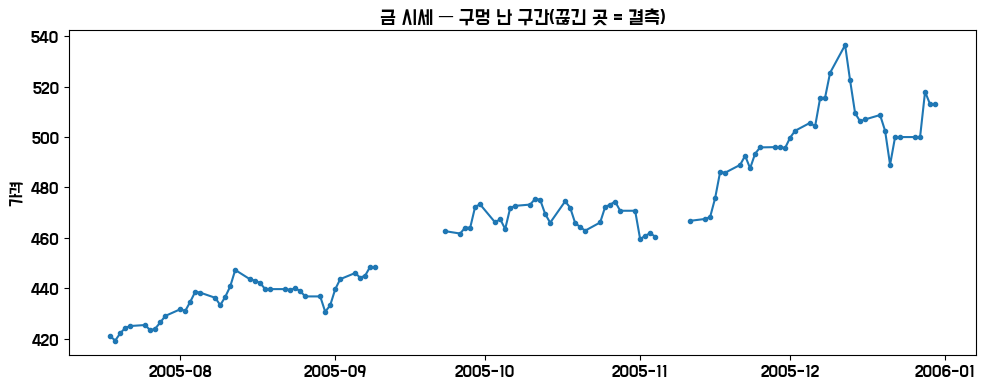

In [15]:
plt.figure(figsize=(10, 4))                 # 가로로 긴 그래프 판 준비
plt.plot(g["ds"], g["y"], marker="o", markersize=3)  # 날짜(x)-가격(y) 선그래프, 점도 표시
plt.title("금 시세 — 구멍 난 구간(끊긴 곳 = 결측)"); plt.ylabel("가격")  # 제목·y축 이름
plt.tight_layout(); plt.show()              # 여백 정리 후 화면에 표시

💡 **해석**: 선이 **뚝뚝 끊긴 구간**이 결측입니다. 눈으로 어디가 비었는지 바로 보이죠. 시계열 결측은 이렇게 그래프로 확인하는 게 가장 빠릅니다.

### B-4. 방법④-a 앞/뒤 값으로 채우기 (ffill/bfill)  🔵
시계열은 *"직전 값"* 으로 채우는 게 자연스러울 때가 많습니다 (어제 가격 ≈ 오늘 가격).

In [16]:
g_ffill = g.copy()                      # 원본 보존 위해 복사본에서 작업
g_ffill["y"] = g_ffill["y"].ffill()     # 빈 칸을 '바로 앞 값'으로 채움(어제 가격≈오늘 가격)
print("ffill 후 결측:", g_ffill["y"].isnull().sum())  # 결측 0인지 확인

ffill 후 결측: 0


💡 **해석**: `ffill()`(forward fill)은 빈 칸을 **직전 값**으로 메웁니다. `bfill()`은 반대로 다음 값. 가격처럼 '갑자기 안 변하는' 데이터에 잘 맞아요. 다만 채운 구간이 '계단처럼' 평평해지는 단점이 있습니다.

### B-5. 방법④-b 보간(interpolate) — 부드럽게 잇기  🟡
구멍의 **양 끝을 직선으로 이어** 자연스럽게 채웁니다. 시계열에 가장 매끄러운 방법.
> 💡 힌트: `g["y"].interpolate()`

In [17]:
g_interp = g.copy()                     # 원본 보존 위해 복사본에서 작업
g_interp["y"] = g_interp["y"].interpolate()    # 구멍의 앞뒤 값을 직선으로 이어 채움(부드럽게)
print("보간 후 결측:", g_interp["y"].isnull().sum())  # 결측 0인지 확인

보간 후 결측: 0


💡 **해석**: `interpolate()`는 빈 구간의 앞뒤를 **직선으로 이어** 채웁니다. 계단처럼 평평한 ffill보다 훨씬 **부드럽고 자연스럽죠**. 다음 셀에서 둘을 그림으로 비교합니다.

### B-6. before / after 비교 시각화  🔵
원본(구멍)·ffill·보간을 한 그림에 겹쳐 봅니다.

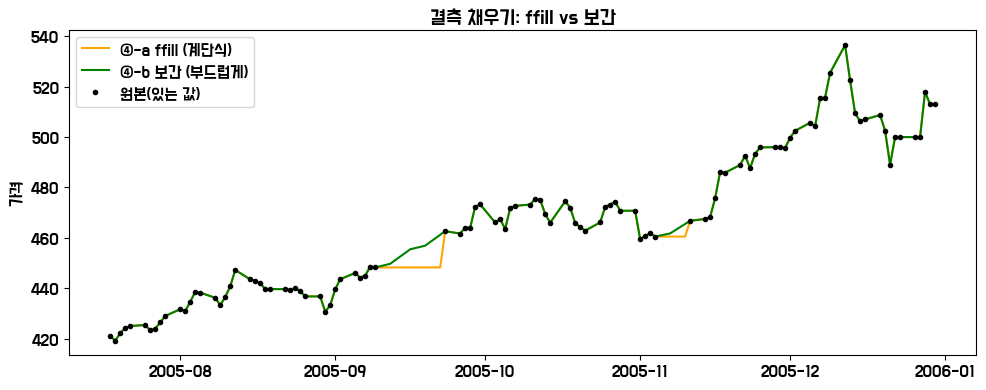

In [18]:
plt.figure(figsize=(10, 4))             # 가로로 긴 그래프 판 준비
plt.plot(g_ffill["ds"], g_ffill["y"], "-", color="orange", label="④-a ffill (계단식)")  # 주황: ffill 결과
plt.plot(g_interp["ds"], g_interp["y"], "-", color="green", label="④-b 보간 (부드럽게)")  # 초록: 보간 결과
plt.plot(g["ds"], g["y"], "o", color="black", markersize=3, label="원본(있는 값)")  # 검은 점: 실제 있던 값
plt.title("결측 채우기: ffill vs 보간"); plt.ylabel("가격"); plt.legend()  # 제목·y축·범례
plt.tight_layout(); plt.show()             # 여백 정리 후 화면에 표시

💡 **해석**: 검은 점(원본 값) 사이의 구멍을, 주황(ffill)은 **수평 계단**으로, 초록(보간)은 **비스듬한 직선**으로 채운 게 보입니다. 시계열엔 보통 **보간**이 더 자연스러워요. *상황에 맞는 방법 선택이 핵심!*

# Part C. 🤖 마지막 — 알고리즘으로 채우기 (KNN)

지금까지는 *한 컬럼만 보고* 채웠습니다(평균, 앞값 등).
하지만 **여러 정보를 함께 보면 더 똑똑하게** 채울 수 있어요.

> 예: 어떤 아파트의 '가격'이 비었다면 → **면적·층·건축년도가 비슷한 다른 아파트들**의 가격을 보고 추정하면 되겠죠?

이게 **KNN(K-최근접 이웃) 대치** 입니다. *"비슷한 이웃들의 값으로 채운다."* — AI/머신러닝에서 쓰는 방법이에요.

### C-1. 작은 샘플 + 결측 만들기  🔵
KNN은 계산이 무거워 **작은 샘플(200건)** 의 수치 컬럼으로 시연합니다.

In [19]:
# [왜 일부러 비우나?] KNN으로 '채우는' 연습을 하려면 채울 빈 칸이 있어야 합니다.
#  그래서 200건 중 15건의 가격을 일부러 비워, "이웃(비슷한 집)을 보고 값을 추정"하는 상황을 만듭니다.
cols = ["전용면적(㎡)", "거래금액(만원)", "층", "건축년도"]  # KNN에 쓸 수치 컬럼 4개
s = apt[cols].sample(200, random_state=42).reset_index(drop=True)  # 200건만 뽑아 줄번호 새로 매김
rng = np.random.default_rng(7)                  # 난수 생성기(7=항상 같은 결과)
miss_idx = rng.choice(s.index, size=15, replace=False)  # 비울 15개 행 무작위 선택
s.loc[miss_idx, "거래금액(만원)"] = np.nan      # 고른 15건의 가격을 빈 칸으로 만듦
print("결측 만든 가격:", s["거래금액(만원)"].isnull().sum(), "건")  # 비운 개수 확인
s.head()                                        # 맨 앞 5줄 미리보기

결측 만든 가격: 15 건


,전용면적(㎡),거래금액(만원),층,건축년도
0,49.80,5500.0,15,1994
1,18.45,NaN,4,2020
2,59.73,59950.0,10,1998
3,40.86,12800.0,2,1988
4,64.29,6400.0,3,1990


💡 **해석**: 면적·금액·층·건축년도 4개 수치 컬럼만 뽑아 200건 샘플을 만들고, 그중 15건의 **가격**을 비웠습니다. 이제 '면적·층·건축년도가 비슷한 이웃'을 보고 가격을 채워볼 거예요.

### C-2. KNN 대치 적용  🔵
`scikit-learn`(코랩 기본 탑재)의 `KNNImputer`. *비슷한 이웃 5명의 평균*으로 빈 칸을 채웁니다.

In [20]:
from sklearn.impute import KNNImputer            # KNN 결측 채우기 도구
from sklearn.preprocessing import StandardScaler   # 단위(스케일) 맞추는 도구

# KNN은 '거리'로 이웃을 찾으므로, 단위가 다른 컬럼은 스케일을 맞춰줍니다(스케일링)
scaler = StandardScaler()                          # 스케일러 준비
scaled = scaler.fit_transform(s)                          # 컬럼별 단위를 맞춤(결측 NaN은 그대로 유지)
imputer = KNNImputer(n_neighbors=5)                # 가장 비슷한 이웃 5명을 보고 채우도록 설정
with np.errstate(all="ignore"):                                   # sklearn 내부 계산의 무해한 경고 숨김
    filled = scaler.inverse_transform(imputer.fit_transform(scaled))  # 이웃 평균으로 채운 뒤 원래 단위로 복원
s_knn = pd.DataFrame(filled, columns=cols)         # 결과를 다시 표(데이터프레임)로
print("KNN 후 결측:", int(s_knn["거래금액(만원)"].isnull().sum()))  # 결측 0인지 확인
print("평균으로만 채웠다면 모두 같은 값이지만, KNN은 행마다 다르게 채웁니다 ↓")
s_knn.loc[miss_idx, "거래금액(만원)"].round(0).head()  # 채워진 값들이 제각각인지 확인

KNN 후 결측: 0
평균으로만 채웠다면 모두 같은 값이지만, KNN은 행마다 다르게 채웁니다 ↓


43     44080.0
175    35980.0
99     25200.0
169    27480.0
160     8440.0
Name: 거래금액(만원), dtype: float64

💡 **해석**: 비었던 15건이 **행마다 다른 값**으로 채워졌습니다 — 각자의 면적·층·건축년도와 비슷한 이웃들을 참고했으니까요.
평균으로 채우면 15건이 *전부 똑같은 값*이 되지만, KNN은 **맥락을 반영**해 더 똑똑하게 채웁니다. 이게 '알고리즘 방식'이에요. (KNN은 거리를 재므로, 단위를 맞추는 '스케일링'을 먼저 했어요.)

### C-3. 평균 채우기 vs KNN 비교 시각화  🔵

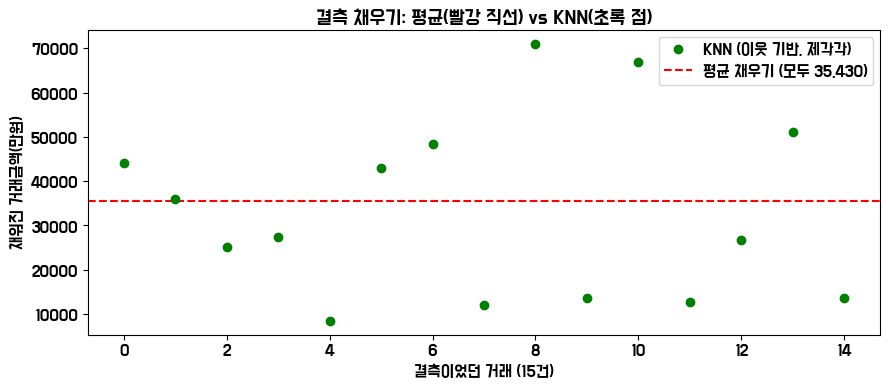

In [21]:
mean_val = s["거래금액(만원)"].mean()  # 비교용: 평균으로 채울 때의 값(하나로 고정)
knn_vals = s_knn.loc[miss_idx, "거래금액(만원)"]  # KNN이 채운 15건의 값들

plt.figure(figsize=(9, 4))                 # 그래프 판 준비
plt.scatter(range(len(knn_vals)), knn_vals, color="green", label="KNN (이웃 기반, 제각각)", zorder=3)  # 초록 점: KNN 값
plt.axhline(mean_val, color="red", ls="--", label=f"평균 채우기 (모두 {mean_val:,.0f})")  # 빨강 직선: 평균(모두 동일)
plt.title("결측 채우기: 평균(빨강 직선) vs KNN(초록 점)")  # 제목
plt.ylabel("채워진 거래금액(만원)"); plt.xlabel("결측이었던 거래 (15건)"); plt.legend()  # 축 이름·범례
plt.tight_layout(); plt.show()             # 여백 정리 후 화면에 표시

💡 **해석**: 빨간 직선(평균)은 모든 결측을 **같은 값**으로 채웁니다. 초록 점(KNN)은 **제각각** — 작은/낡은 집은 낮게, 크고 좋은 집은 높게 추정됐죠. 무조건 KNN이 정답은 아니지만, 변수 간 관계가 있을 때 강력합니다.

*(참고: 회귀로 채우는 `IterativeImputer` 같은 더 정교한 방법도 있어요 — 더 공부하면 만나게 됩니다!)*

## 🎯 정리 — 결측치 처리, 이렇게 고른다

| 방법 | 어떻게 | 언제 쓰나 | 오늘 사용 |
|---|---|---|---|
| ① 컬럼 버리기 | `drop(columns=...)` | 거의 다 비었을 때 | 해제사유발생일 |
| ② 행 버리기 | `dropna()` | 결측이 아주 적을 때 | 번지·본번 |
| ③ 대표값 채우기 | `fillna(중앙값/평균/최빈값)` | 일반적, 빠르게 | 거래금액(중앙값) |
| ④ 앞뒤값 / 보간 | `ffill()` / `interpolate()` | **시계열**(시간순) | 금 시세 |
| ⑤ 알고리즘(KNN) | `KNNImputer` | 변수 간 관계 활용 | 가격 추정 |

**핵심**: 결측 처리에 '정답'은 없습니다. **데이터의 성격(범주형/수치형/시계열)** 과 **결측의 양**을 보고 **사람이 판단**해 고릅니다. — 1교시의 그 메시지, 기억나죠?

> 🏠 **셀프스터디**: 이 노트북의 부동산 데이터로 ③을 '평균'으로 바꿔보거나, 금융 데이터의 보간을 `method="spline"` 으로 바꿔보세요. 결과가 어떻게 달라지는지 직접 비교!